In [11]:
import sys
import os
# Adds the parent directory of 'notebook' (the project root) to the search path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils.config import RANDOM_STATE
from src.data.load_data import load
from src.features.build_features import build
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
X = df.drop("Class",axis=1)
y = df["Class"]

In [3]:

X_train,y_train,X_test,y_test = build(X,y)

In [4]:
X_train.shape

(228572, 30)

In [5]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,RocCurveDisplay
def report_model(model,X_test,y_test):
    pred = model.predict(X_test)

    print(classification_report(y_test,pred))

    ConfusionMatrixDisplay.from_predictions(y_test,pred)
    plt.title("Confusion matrix")
    plt.show()

    print("\n"*2)

    RocCurveDisplay.from_predictions(y_test,pred)
    plt.title("ROC")
    plt.show()




              precision    recall  f1-score   support

           0       1.00      0.98      0.99     93838
           1       0.06      0.92      0.10       149

    accuracy                           0.97     93987
   macro avg       0.53      0.95      0.55     93987
weighted avg       1.00      0.97      0.99     93987



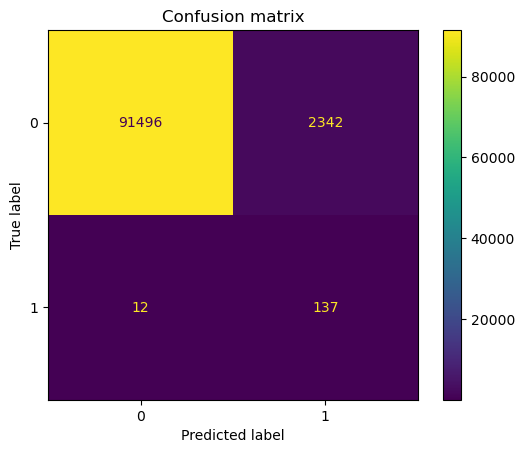

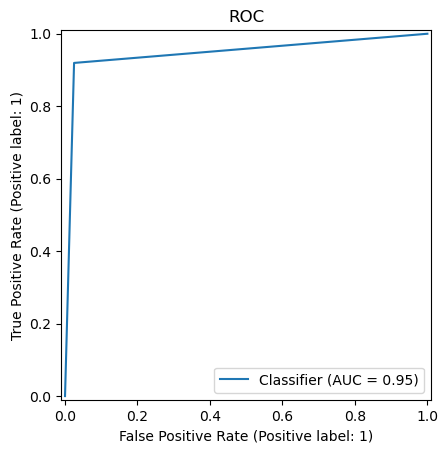

In [6]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train,y_train)
report_model(model,X_test,y_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END max_depth=15, max_features=log2, n_estimators=150;, score=0.999 total time= 1.3min
[CV 2/3] END max_depth=15, max_features=log2, n_estimators=150;, score=0.999 total time= 1.3min
[CV 3/3] END max_depth=15, max_features=log2, n_estimators=150;, score=0.998 total time= 1.3min
[CV 1/3] END max_depth=15, max_features=log2, n_estimators=100;, score=0.998 total time=  51.0s
[CV 2/3] END max_depth=15, max_features=log2, n_estimators=100;, score=0.999 total time=  50.5s
[CV 3/3] END max_depth=15, max_features=log2, n_estimators=100;, score=0.998 total time=  51.9s
[CV 1/3] END max_depth=10, max_features=sqrt, n_estimators=100;, score=0.994 total time=  52.6s
[CV 2/3] END max_depth=10, max_features=sqrt, n_estimators=100;, score=0.995 total time=  52.4s
[CV 3/3] END max_depth=10, max_features=sqrt, n_estimators=100;, score=0.994 total time=  52.1s
[CV 1/3] END max_depth=15, max_features=sqrt, n_estimators=200;, score=0.99

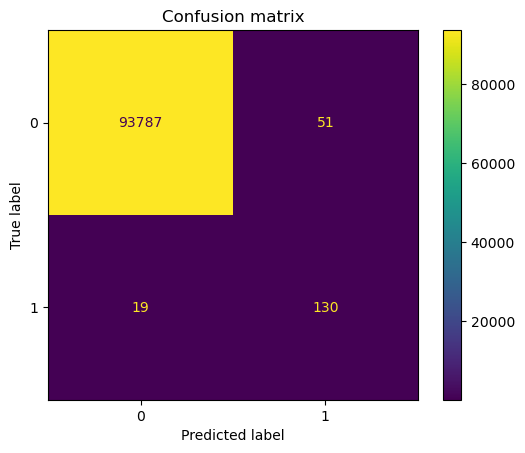

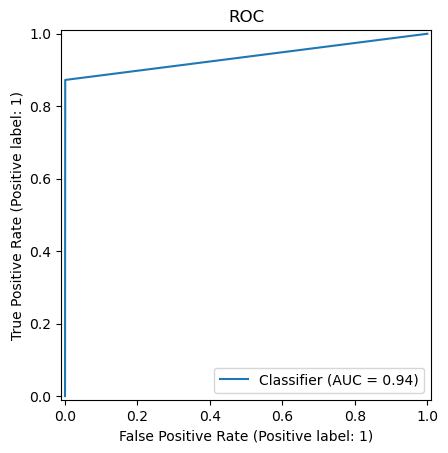

In [13]:
##Random Forrest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')

param_grid = {'n_estimators' : [100,150,200],
              'max_depth' : [10,15],
              'max_features' : ['sqrt','log2']}

from sklearn.model_selection import RandomizedSearchCV #as grid search is taking too much time

grid = RandomizedSearchCV(estimator=model,
                          param_distributions=param_grid,
                          cv=3,
                          n_jobs=1,
                          verbose=3,
                          random_state=RANDOM_STATE)

grid.fit(X_train,y_train)

report_model(grid.best_estimator_,X_test,y_test)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     93838
           1       0.10      0.90      0.18       149

    accuracy                           0.99     93987
   macro avg       0.55      0.94      0.59     93987
weighted avg       1.00      0.99      0.99     93987



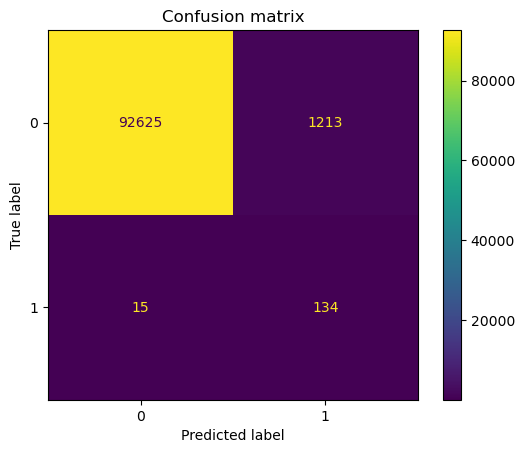

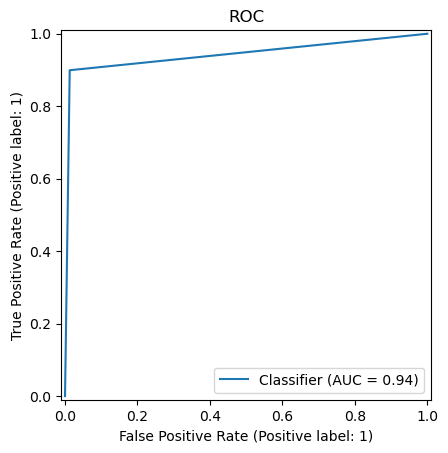

In [8]:
##Support Vector Classifier
from sklearn.svm import SVC

model = SVC(class_weight='balanced')

model.fit(X_train,y_train)

report_model(model,X_test,y_test)



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93838
           1       0.37      0.90      0.53       149

    accuracy                           1.00     93987
   macro avg       0.69      0.95      0.76     93987
weighted avg       1.00      1.00      1.00     93987



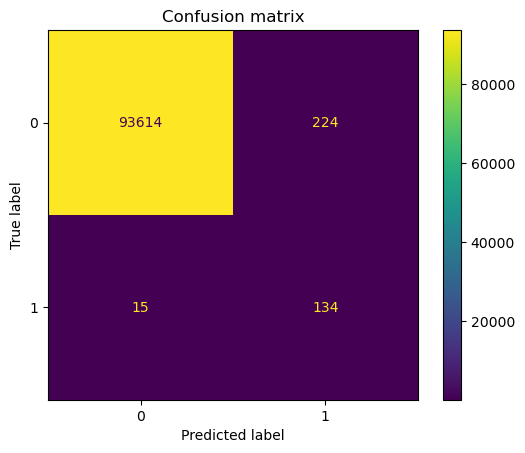

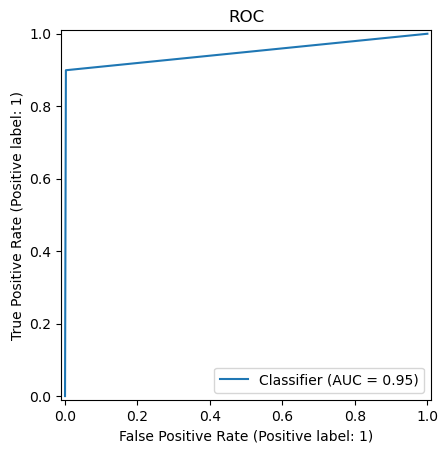

In [10]:
##Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()

model.fit(X_train,y_train)

report_model(model,X_test,y_test)